# LiDAR Years All — Data Understanding
New all-years dataset (`LiDAR_Years_All_7jul.gpkg`). Six LiDAR surveys: 2002, 2006, 2008, 2012, 2021, 2023.
Run from top to bottom; figures are saved to `notebooks/figures/lidar_years_all_data_understanding/`.


In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})


In [2]:
notebook_name = "lidar_years_all_data_understanding"

starting_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [starting_directory, *starting_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)

GPKG_PATH = project_root / "data" / "raw" / "LiDAR_Years_All_7jul.gpkg"
LAYER_ALL = "LiDAR_Years"
LAYER_SS  = "LiDAR_Years_SS"

assert GPKG_PATH.exists(), f"GeoPackage not found: {GPKG_PATH}"
print("Project root:", project_root)
print("GeoPackage:  ", GPKG_PATH)


Project root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss
GeoPackage:   /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/data/raw/LiDAR_Years_All_7jul.gpkg


In [3]:
# Load attributes without geometry — fast path for all non-spatial analysis.
df = gpd.read_file(GPKG_PATH, layer=LAYER_ALL, ignore_geometry=True)
df_ss = gpd.read_file(GPKG_PATH, layer=LAYER_SS, ignore_geometry=True)
print(f"LiDAR_Years    : {len(df):,} rows × {df.shape[1]} columns")
print(f"LiDAR_Years_SS : {len(df_ss):,} rows × {df_ss.shape[1]} columns")
print(f"CRS stored in GeoPackage — loaded with geometry below where needed.")


LiDAR_Years    : 795,645 rows × 38 columns
LiDAR_Years_SS : 376,080 rows × 38 columns
CRS stored in GeoPackage — loaded with geometry below where needed.


---
## 1. Dataset Overview


In [4]:
# Shape, columns, dtypes.
print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")
df.dtypes.to_frame("dtype")


Rows: 795,645   Columns: 38


,dtype
LiDAR_year,int32
identification,int32
CanopyCover,float64
GapFraction,float64
LAI,float64
elev_percentile_95th,float64
elev_percentile_99th,float64
AOI,str
block,int32
SPIS_RF,float64


In [5]:
# Survey years and plot counts.
year_summary = (
    df.groupby("LiDAR_year")
    .agg(
        rows=("identification", "size"),
        unique_plots=("identification", "nunique"),
    )
    .assign(rows_per_plot=lambda t: (t["rows"] / t["unique_plots"]).round(2))
)
print("Available LiDAR years:")
year_summary


Available LiDAR years:


,rows,unique_plots,rows_per_plot
LiDAR_year,,,
2002,37888,37888,1.0
2006,22538,22538,1.0
2008,114975,114975,1.0
2012,173550,173550,1.0
2021,218359,218359,1.0
2023,228335,228335,1.0


In [6]:
# Duplicate plot-year pairs.
dup_count = df.duplicated(["identification", "LiDAR_year"]).sum()
print(f"Duplicate plot-year pairs: {dup_count:,}")


Duplicate plot-year pairs: 0


In [7]:
# Missing values per column.
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_rows": missing, "pct": missing_pct})
missing_df = missing_df[missing_df["missing_rows"] > 0].sort_values("missing_rows", ascending=False)
missing_df


,missing_rows,pct
p1,20180,2.54
p2,20180,2.54
p3,20180,2.54
p4,20180,2.54
p5,20180,2.54
GYCspec95,20180,2.54
GYCspec99,20180,2.54
g1,5102,0.64
g3,5102,0.64
Vol95,5102,0.64


In [8]:
# Zero-coded sentinel values — fields where 0 means 'not recorded', not a real zero.
sentinel_cols = ["plyr", "yldc", "next_thin_", "last_thinn", "flyr"]
sentinel_summary = pd.DataFrame({
    col: {
        "zero_rows": df[col].eq(0).sum(),
        "zero_pct": round(df[col].eq(0).mean() * 100, 2),
    }
    for col in sentinel_cols if col in df.columns
}).T
sentinel_summary


,zero_rows,zero_pct
plyr,0.0,0.00
yldc,0.0,0.00
next_thin_,16723.0,2.10
last_thinn,616755.0,77.52
flyr,795645.0,100.00


In [9]:
# Infinite values (GYCspec columns are known to have them).
inf_check = {}
for col in df.select_dtypes("number").columns:
    n_inf = np.isinf(df[col].dropna()).sum()
    if n_inf > 0:
        inf_check[col] = n_inf
print("Columns with infinite values:", inf_check if inf_check else "None")


Columns with infinite values: {'GYCspec95': np.int64(4278), 'GYCspec99': np.int64(4278)}


### Summary — Dataset Overview
- Six LiDAR surveys: 2002, 2006, 2008, 2012, 2021, 2023. Later years have substantially more plots (2021/2023 are the bulk of the data).
- 39 columns vs 24 in the v1 dataset. New columns include `Species`, `p1–p5`, `whcl`, `flyr`, `Thin`, `g1`, `g3`, `Top_Height99`, `Vol99`, `Vol_RM95`, `GYCspec95`, `GYCspec99`.
- No duplicate plot-year pairs.
- Missing values concentrated in `p1–p5`, `GYCspec95/99`, `Vol95/99`, `g1/g3` (~5 102 rows) and `SPIS_RF`/`Species` (~827 rows).
- `flyr` is all zeros — it carries no information.
- `GYCspec95` and `GYCspec99` contain 4 278 infinite values each; filter before use.
- `plyr` minimum is 1870 — older than in v1 but plausible for ancient stands; the `plyr=0` artefact from v1 appears resolved.


---
## 2. Spatial and Temporal Coverage


In [10]:
# Load geometry for spatial work (slower — done once here).
gdf = gpd.read_file(GPKG_PATH, layer=LAYER_ALL)
print(f"CRS: {gdf.crs}")
print(f"Geometry types: {gdf.geom_type.value_counts().to_dict()}")


CRS: EPSG:27700
Geometry types: {'MultiPolygon': 795645}


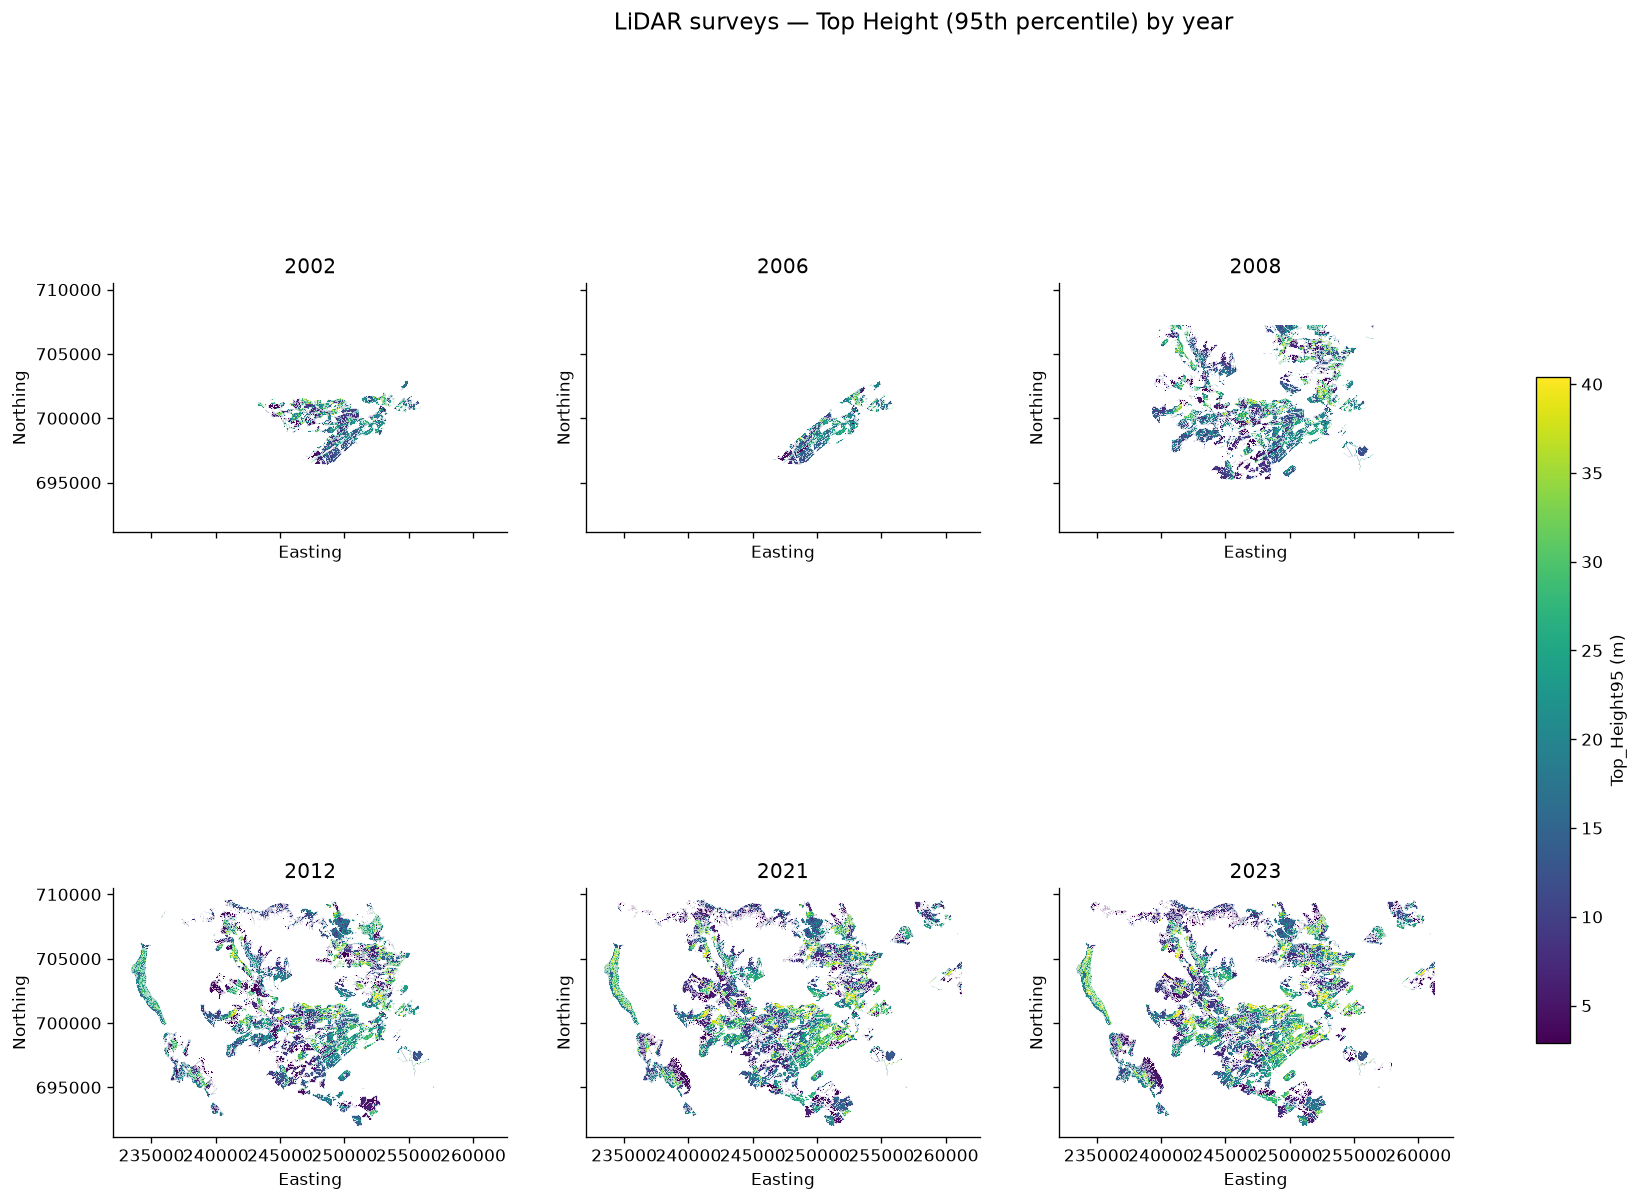

In [15]:
# One map per LiDAR year, coloured by Top_Height95.
h_min, h_max = gdf["Top_Height95"].quantile([0.01, 0.99])
fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharex=True, sharey=True)

for ax, (year, grp) in zip(axes.flat, gdf.groupby("LiDAR_year")):
    grp.plot(column="Top_Height95", cmap="viridis",
             vmin=h_min, vmax=h_max, linewidth=0, ax=ax)
    ax.set_title(str(year))
    ax.set_xlabel("Easting")
    ax.set_ylabel("Northing")
    ax.set_aspect("equal")

sm = ScalarMappable(Normalize(h_min, h_max), cmap="viridis")
fig.colorbar(sm, ax=axes, shrink=0.6, label="Top_Height95 (m)")
fig.suptitle("LiDAR surveys — Top Height (95th percentile) by year", fontsize=14)
plt.show()


In [16]:
# Forest spatial extent: total area of surveyed polygons per year.
gdf["poly_area_m2"] = gdf.geometry.area
extent_by_year = (
    gdf.groupby("LiDAR_year")["poly_area_m2"]
    .sum()
    .div(1e6)
    .rename("total_area_km2")
    .round(2)
)
print("Surveyed area per year (km²):")
print(extent_by_year.to_string())


Surveyed area per year (km²):
LiDAR_year
2002     16.89
2006      9.96
2008     51.44
2012     77.94
2021     98.21
2023    102.70


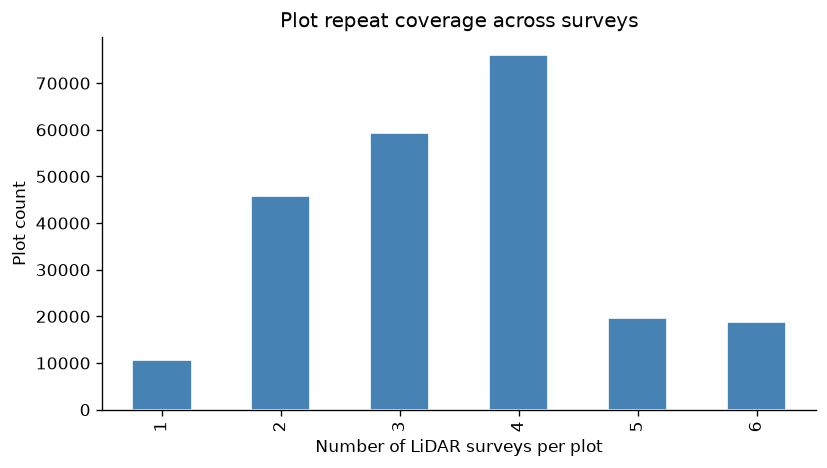

LiDAR_year
1    10608
2    45871
3    59417
4    76052
5    19630
6    18781


In [18]:
# How many unique plots appear in multiple survey years?
plot_year_counts = df.groupby("identification")["LiDAR_year"].nunique()
repeat_dist = plot_year_counts.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
repeat_dist.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Number of LiDAR surveys per plot")
ax.set_ylabel("Plot count")
ax.set_title("Plot repeat coverage across surveys")
plt.tight_layout()
plt.show()
print(repeat_dist.to_string())


In [19]:
# Which year pairs share the most plots?
years = sorted(df["LiDAR_year"].unique())
id_sets = {yr: set(df.loc[df["LiDAR_year"].eq(yr), "identification"]) for yr in years}
overlap = pd.DataFrame(
    {yr_a: {yr_b: len(id_sets[yr_a] & id_sets[yr_b]) for yr_b in years} for yr_a in years},
    index=years, columns=years,
)
print("Shared plot counts between survey years:")
overlap


Shared plot counts between survey years:


,2002,2006,2008,2012,2021,2023
2002,37888,20169,37418,37635,36627,36654
2006,20169,22538,22356,22391,21175,21209
2008,37418,22356,114975,114413,113339,113457
2012,37635,22391,114413,173550,171764,171934
2021,36627,21175,113339,171764,218359,217908
2023,36654,21209,113457,171934,217908,228335


### Summary — Spatial and Temporal Coverage
- The forest footprint grows noticeably between earlier and later surveys, reflecting survey expansion rather than forest growth alone.
- 2002 and 2006 surveys cover substantially smaller areas than 2008–2023; spatial coverage is not uniform across years.
- Many plots appear in only one or two surveys; full six-year trajectories will be a minority of the total.
- The overlap matrix is key for understanding cohort sizes: the four-year cohort (2008, 2012, 2021, 2023) and six-year cohort (all years) will have very different spatial extents.


---
## 3. Key Forest Variables


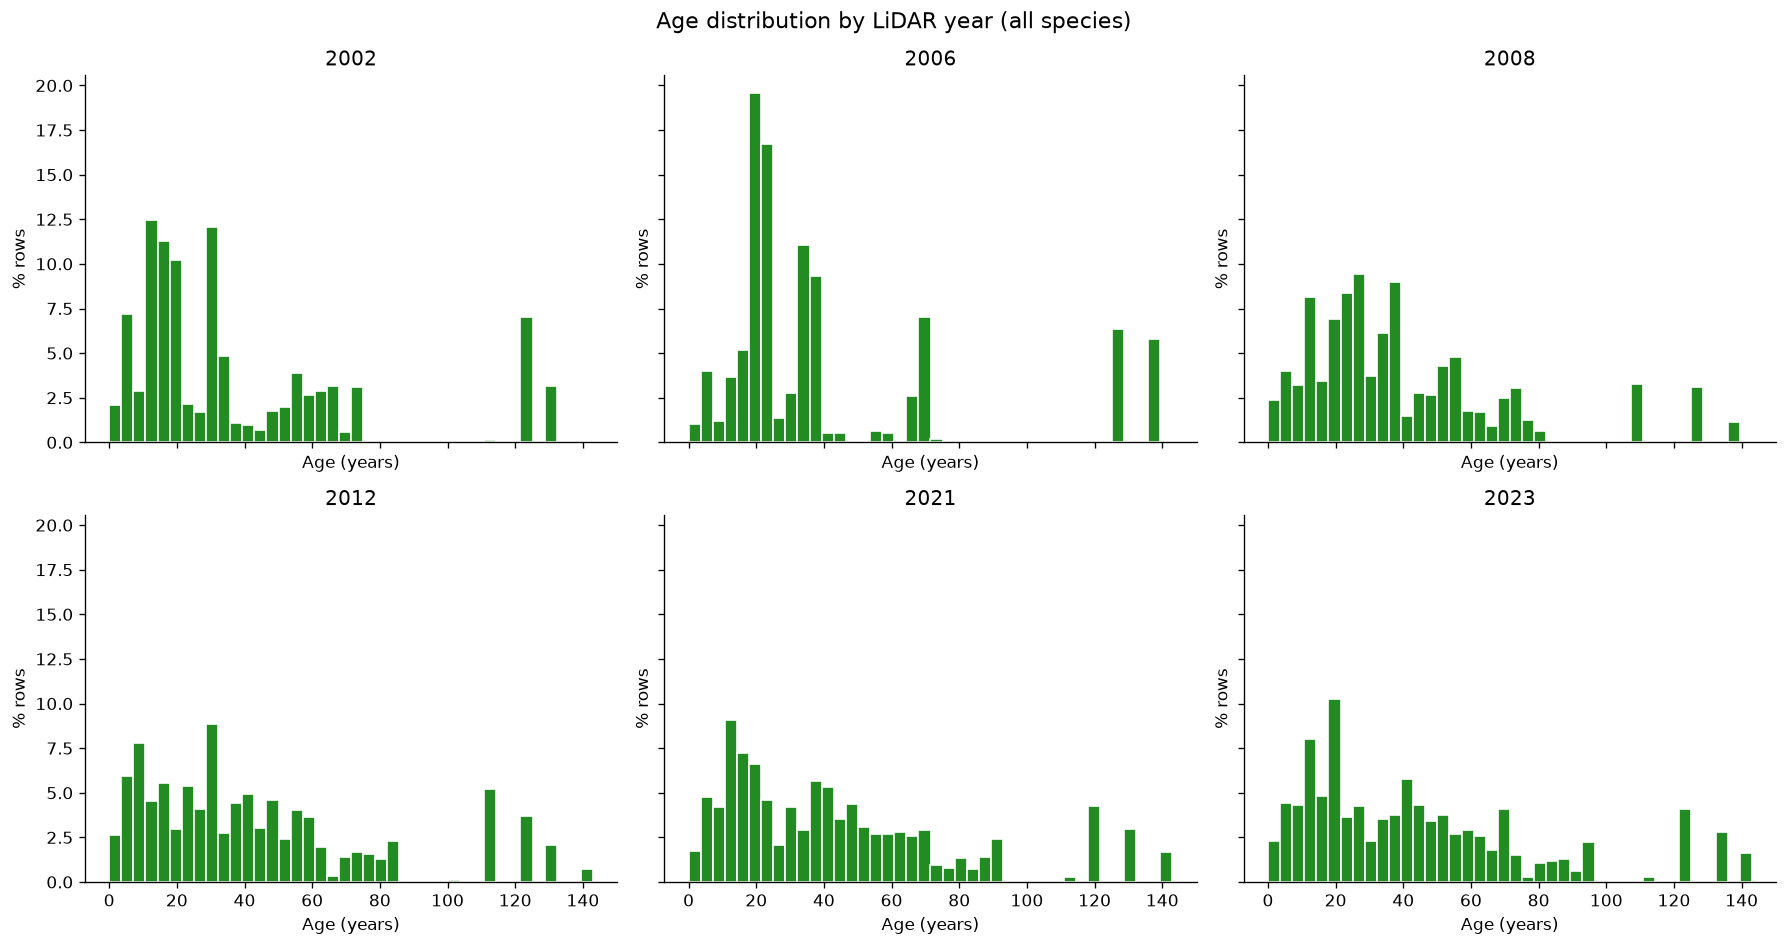

In [20]:
# ── Age ──
all_ages = df["Age"].dropna()
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
age_bins = np.linspace(0, min(all_ages.max(), 160), 41)

for ax, (yr, grp) in zip(axes.flat, df.groupby("LiDAR_year")):
    ages = grp["Age"].dropna()
    w = np.ones(len(ages)) * 100 / len(ages)
    ax.hist(ages, bins=age_bins, weights=w, color="forestgreen", edgecolor="white")
    ax.set_title(str(yr))
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("% rows")

fig.suptitle("Age distribution by LiDAR year (all species)", fontsize=13)
plt.tight_layout()
plt.show()


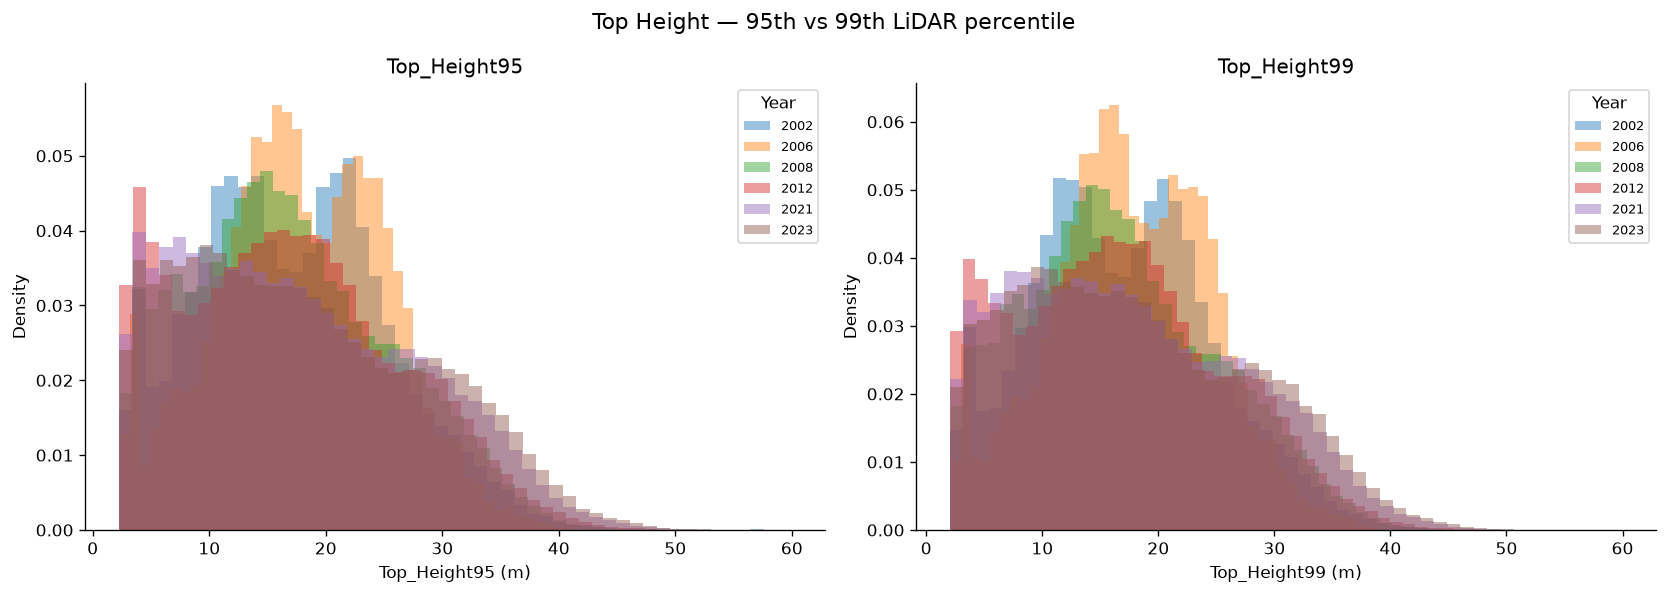

       Top_Height95  Top_Height99
count     795645.00     795645.00
mean          17.63         17.39
std            9.60          9.22
min            2.25          2.05
25%            9.82         10.03
50%           16.59         16.45
75%           24.46         23.94
max           59.96         59.99

Top_Height99 − Top_Height95 : mean=-0.241 m   std=0.816 m
  99th < 95th in 504,668 rows (63.4%)


In [21]:
# ── Top Height: 95th vs 99th percentile ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ["Top_Height95", "Top_Height99"]):
    for yr, grp in df.groupby("LiDAR_year"):
        vals = grp[col].dropna()
        ax.hist(vals, bins=50, alpha=0.45, label=str(yr), density=True)
    ax.set_xlabel(f"{col} (m)")
    ax.set_ylabel("Density")
    ax.set_title(col)
    ax.legend(title="Year", fontsize=8)

fig.suptitle("Top Height — 95th vs 99th LiDAR percentile", fontsize=13)
plt.tight_layout()
plt.show()

# Numeric comparison
print(df[["Top_Height95", "Top_Height99"]].describe().round(2))
print()
diff = (df["Top_Height99"] - df["Top_Height95"])
print(f"Top_Height99 − Top_Height95 : mean={diff.mean():.3f} m   std={diff.std():.3f} m")
print(f"  99th < 95th in {(diff < 0).sum():,} rows ({(diff<0).mean()*100:.1f}%)")


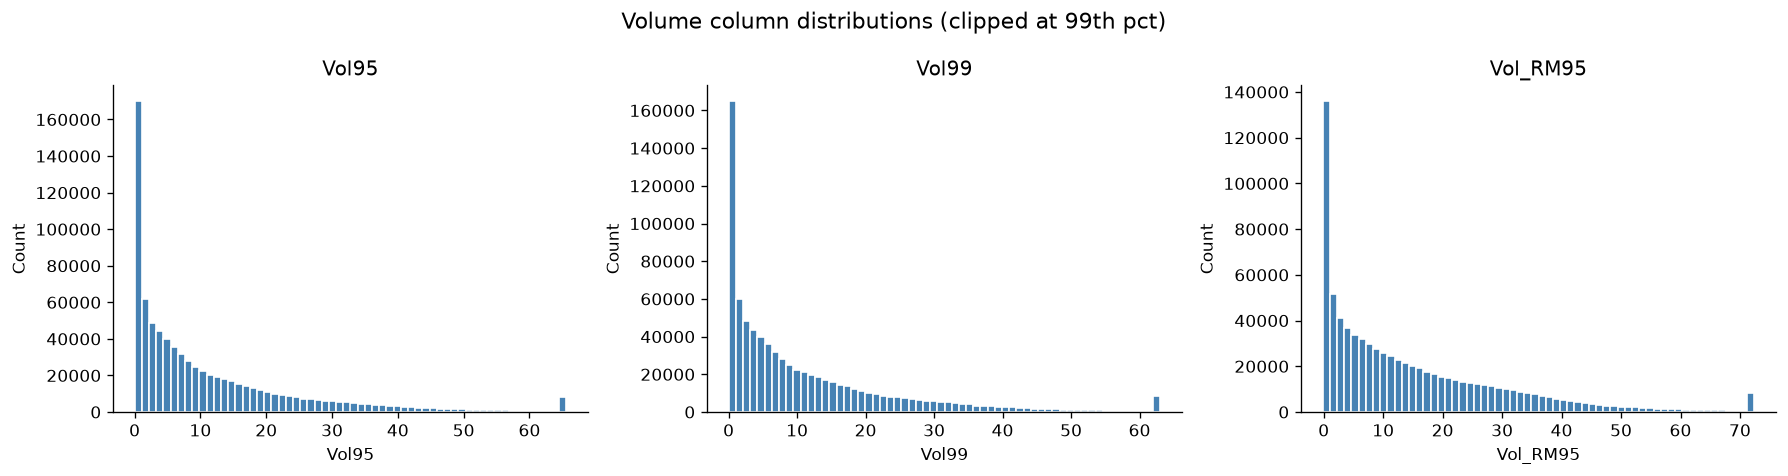

            Vol95       Vol99    Vol_RM95
count  790543.000  790543.000  795645.000
mean       11.549      11.217      14.977
std        14.546      13.922      16.328
min         0.000       0.000      -0.190
25%         1.543       1.590       2.544
50%         6.395       6.376       9.934
75%        16.209      15.781      22.534
max       233.265     241.544     256.096

Negative Vol_RM95 rows: 23,415


In [22]:
# ── Volume: Vol95, Vol99, Vol_RM95 ──
vol_cols = ["Vol95", "Vol99", "Vol_RM95"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, vol_cols):
    vals = df[col].dropna()
    clip = vals.clip(upper=vals.quantile(0.99))
    ax.hist(clip, bins=60, color="steelblue", edgecolor="white")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.set_title(col)

fig.suptitle("Volume column distributions (clipped at 99th pct)", fontsize=13)
plt.tight_layout()
plt.show()
print(df[vol_cols].describe().round(3))
print(f"\nNegative Vol_RM95 rows: {df['Vol_RM95'].lt(0).sum():,}")


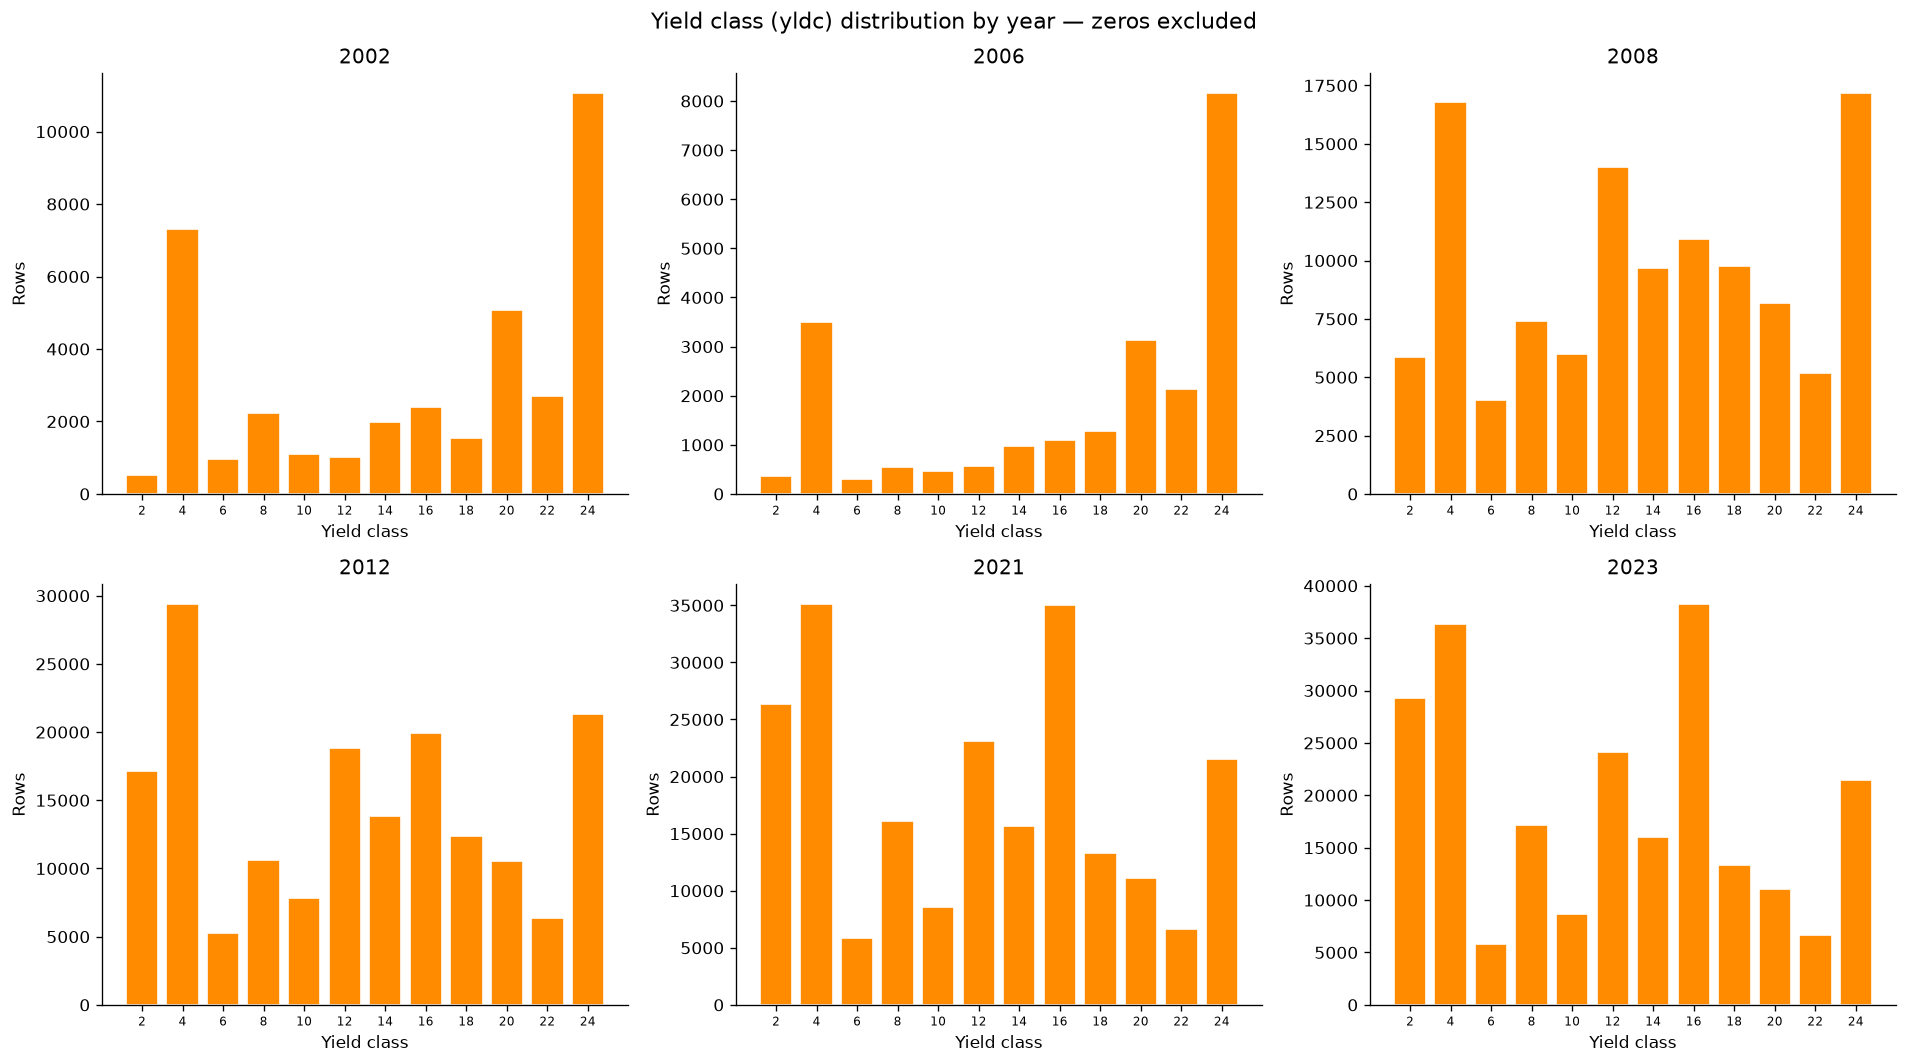

In [23]:
# ── Yield class ──
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
yldc_levels = sorted(df["yldc"].replace(0, np.nan).dropna().unique())

for ax, (yr, grp) in zip(axes.flat, df.groupby("LiDAR_year")):
    counts = grp["yldc"].replace(0, np.nan).value_counts().reindex(yldc_levels, fill_value=0)
    ax.bar(counts.index.astype(str), counts.values, color="darkorange", edgecolor="white")
    ax.set_title(str(yr))
    ax.set_xlabel("Yield class")
    ax.set_ylabel("Rows")
    ax.tick_params(axis="x", labelsize=7)

fig.suptitle("Yield class (yldc) distribution by year — zeros excluded", fontsize=13)
plt.tight_layout()
plt.show()


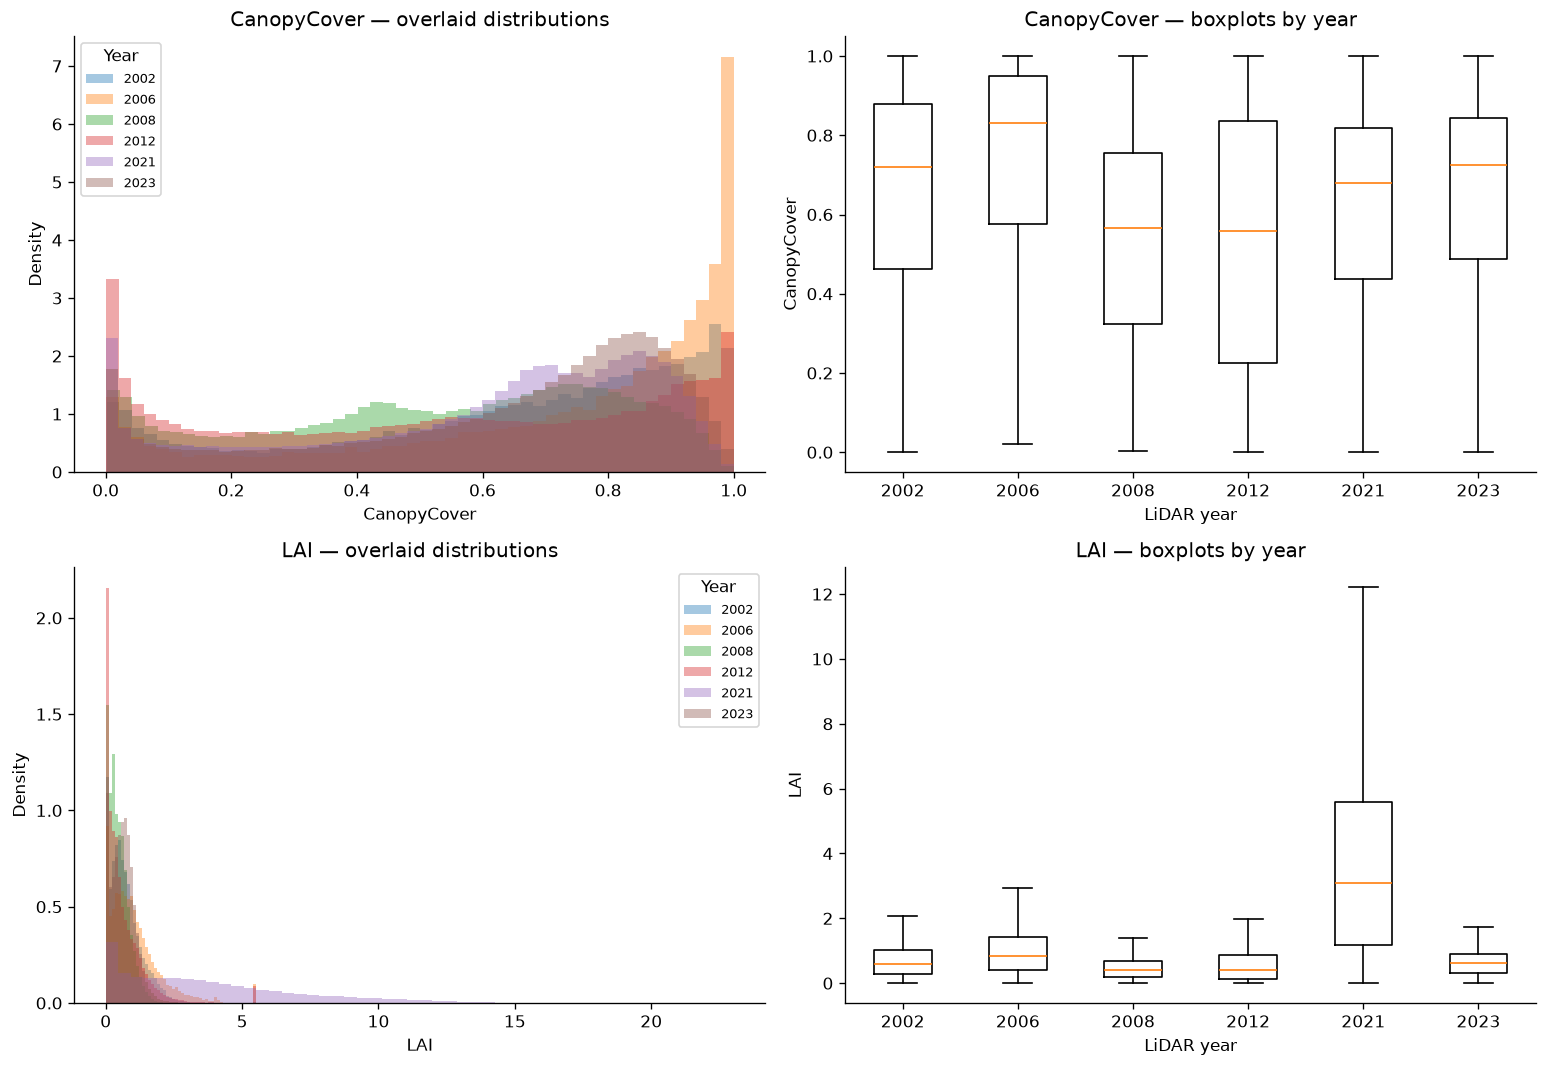

LAI == 5.5 (sensor ceiling?): 1,992 rows (0.3%)


In [26]:
# ── Canopy cover and LAI ──
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for col, axrow in zip(["CanopyCover", "LAI"], axes):
    for ax, yr in zip(axrow, [None, "box"]):
        if yr is None:
            for survey_yr, grp in df.groupby("LiDAR_year"):
                vals = grp[col].dropna()
                ax.hist(vals, bins=50, alpha=0.4, density=True, label=str(survey_yr))
            ax.set_xlabel(col)
            ax.set_ylabel("Density")
            ax.set_title(f"{col} — overlaid distributions")
            ax.legend(title="Year", fontsize=8)
        else:
            data_box = [df.loc[df["LiDAR_year"].eq(y), col].dropna() for y in sorted(df["LiDAR_year"].unique())]
            #ax.boxplot(data_box, labels=[str(y) for y in sorted(df["LiDAR_year"].unique())], showfliers=False)
            years = sorted(df["LiDAR_year"].dropna().unique())
            data_box = [df.loc[df["LiDAR_year"].eq(year), col].dropna() for year in years]
            ax.boxplot(data_box,tick_labels=[str(year) for year in years],showfliers=False,)
            ax.set_xlabel("LiDAR year")
            ax.set_ylabel(col)
            ax.set_title(f"{col} — boxplots by year")

plt.tight_layout()
plt.show()

# Flag known LAI ceiling
lai_cap = df["LAI"].eq(5.5).sum()
print(f"LAI == 5.5 (sensor ceiling?): {lai_cap:,} rows ({lai_cap/len(df)*100:.1f}%)")


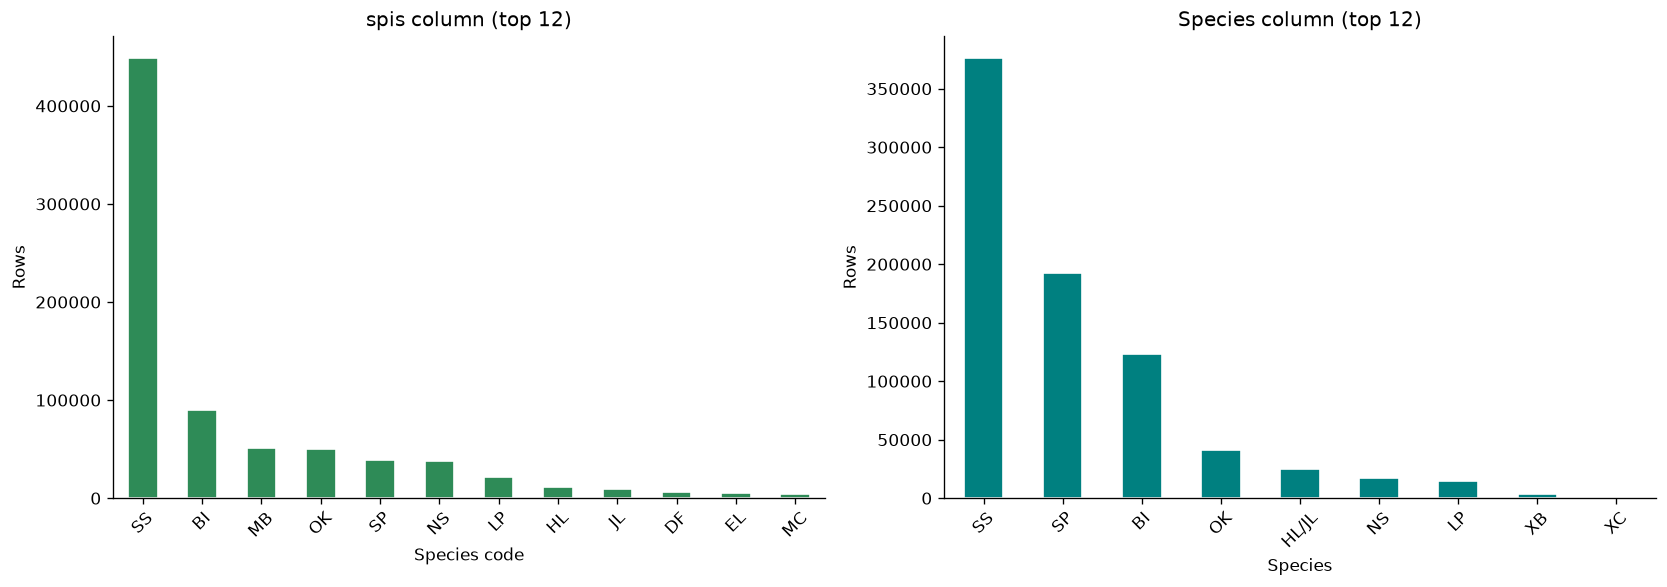

spis ≠ Species in 381,526 rows (48.0%)

Top 10 spis/Species combinations:
spis  Species
SS    SS         306664
      SP         106417
BI    BI          50797
SP    SP          23712
MB    BI          23014
OK    OK          21888
BI    SP          21114
NS    SS          19725
OK    BI          17605
SS    BI          14893


In [27]:
# ── Species breakdown ──
# spis vs Species — they don't always agree
spis_counts = df["spis"].value_counts().head(12)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

spis_counts.plot(kind="bar", ax=axes[0], color="seagreen", edgecolor="white")
axes[0].set_title("spis column (top 12)")
axes[0].set_xlabel("Species code")
axes[0].set_ylabel("Rows")
axes[0].tick_params(axis="x", rotation=45)

species_counts = df["Species"].value_counts().head(12)
species_counts.plot(kind="bar", ax=axes[1], color="teal", edgecolor="white")
axes[1].set_title("Species column (top 12)")
axes[1].set_xlabel("Species")
axes[1].set_ylabel("Rows")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Mismatch rate
mismatch = df["spis"].ne(df["Species"]).sum()
print(f"spis ≠ Species in {mismatch:,} rows ({mismatch/len(df)*100:.1f}%)")
print("\nTop 10 spis/Species combinations:")
print(df.groupby(["spis","Species"]).size().sort_values(ascending=False).head(10).to_string())


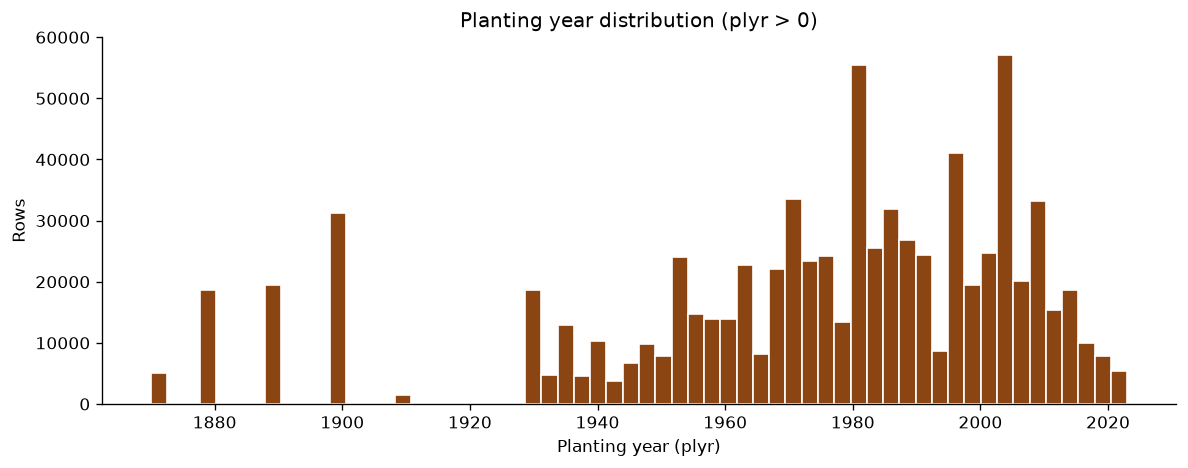

count    795645.000000
mean       1972.891261
std          34.633392
min        1870.000000
25%        1957.000000
50%        1981.000000
75%        2000.000000
max        2023.000000
Name: plyr, dtype: float64

Rows with plyr == 0: 0
Rows with plyr < 1850: 0


In [28]:
# ── Planting year ──
fig, ax = plt.subplots(figsize=(10, 4))
valid_plyr = df.loc[df["plyr"].gt(0), "plyr"]
ax.hist(valid_plyr, bins=60, color="saddlebrown", edgecolor="white")
ax.set_xlabel("Planting year (plyr)")
ax.set_ylabel("Rows")
ax.set_title("Planting year distribution (plyr > 0)")
plt.tight_layout()
plt.show()
print(valid_plyr.describe())
print(f"\nRows with plyr == 0: {df['plyr'].eq(0).sum():,}")
print(f"Rows with plyr < 1850: {df['plyr'].lt(1850).sum():,}")


In [29]:
# ── Thinning ──
thin_counts = df["Thin"].value_counts().sort_index()
print("Thin value counts:")
print(thin_counts.to_string())

# Wind hazard class
whcl_counts = df["whcl"].value_counts().sort_index()
print("\nWind hazard class (whcl) distribution:")
print(whcl_counts.to_string())


Thin value counts:
Thin
0.0    616755
1.0    178890

Wind hazard class (whcl) distribution:
whcl
0     20962
1      7718
2    136910
3    119152
4    393416
5     70104
6     47383


In [30]:
# ── g1 / g3 — volume equation coefficients (NOT independent variables) ──
print("g1 unique values:", sorted(df["g1"].dropna().unique()))
print("g3 unique values:", sorted(df["g3"].dropna().unique()))
print()
# Cross-tab with Thin to show they encode thinning status
g_thin = df.dropna(subset=["g1","g3"]).groupby(["g1","g3","Thin"]).size().reset_index(name="rows")
print("g1 / g3 / Thin cross-tab (showing these are lookup parameters):")
print(g_thin.sort_values("rows", ascending=False).to_string(index=False))


g1 unique values: [np.float64(0.123183), np.float64(1.279552), np.float64(1.648721), np.float64(2.023301), np.float64(2.028465), np.float64(2.066719), np.float64(2.10137), np.float64(2.922183), np.float64(3.509144), np.float64(4.686913)]
g3 unique values: [np.float64(1.225744), np.float64(1.478136), np.float64(1.549929), np.float64(1.66965), np.float64(1.694732), np.float64(1.715591), np.float64(1.71684), np.float64(1.831874), np.float64(1.96478), np.float64(2.453028)]

g1 / g3 / Thin cross-tab (showing these are lookup parameters):
      g1       g3  Thin   rows
2.922183 1.694732   0.0 264886
1.279552 1.964780   0.0 170849
0.123183 2.453028   0.0 116153
3.509144 1.478136   1.0 111194
1.648721 1.715591   1.0  37061
4.686913 1.225744   0.0  32769
2.101370 1.716840   0.0  18845
2.066719 1.831874   0.0   9054
4.686913 1.225744   1.0   8665
2.023301 1.669650   1.0   7813
0.123183 2.453028   1.0   7135
2.028465 1.549929   1.0   6119


In [31]:
# ── p1–p5 — tabulated growth parameters ──
p_cols = ["p1","p2","p3","p4","p5"]
for c in p_cols:
    n_uniq = df[c].dropna().nunique()
    vals = sorted(df[c].dropna().unique())
    print(f"{c}: {n_uniq} unique values → {[round(v,4) for v in vals]}")


p1: 6 unique values → [np.float64(11.3238), np.float64(12.9279), np.float64(14.1305), np.float64(14.3809), np.float64(14.4207), np.float64(14.8559)]
p2: 6 unique values → [np.float64(1.1446), np.float64(1.4688), np.float64(1.4739), np.float64(1.7198), np.float64(1.7781), np.float64(2.8342)]
p3: 4 unique values → [np.float64(-1.1423), np.float64(-0.4563), np.float64(-0.2374), np.float64(0.0)]
p4: 6 unique values → [np.float64(0.0221), np.float64(0.0238), np.float64(0.0252), np.float64(0.0284), np.float64(0.0351), np.float64(0.0408)]
p5: 6 unique values → [np.float64(1.0617), np.float64(1.1183), np.float64(1.2549), np.float64(1.321), np.float64(1.4931), np.float64(1.9237)]


GYCspec95 (finite only):
count    771187.00
mean         29.16
std         199.60
min         -10.25
25%           7.23
50%          17.47
75%          25.43
max       17439.80
Name: GYCspec95, dtype: float64

Infinite values in GYCspec95: 4,278
Infinite values in GYCspec99: 4,278


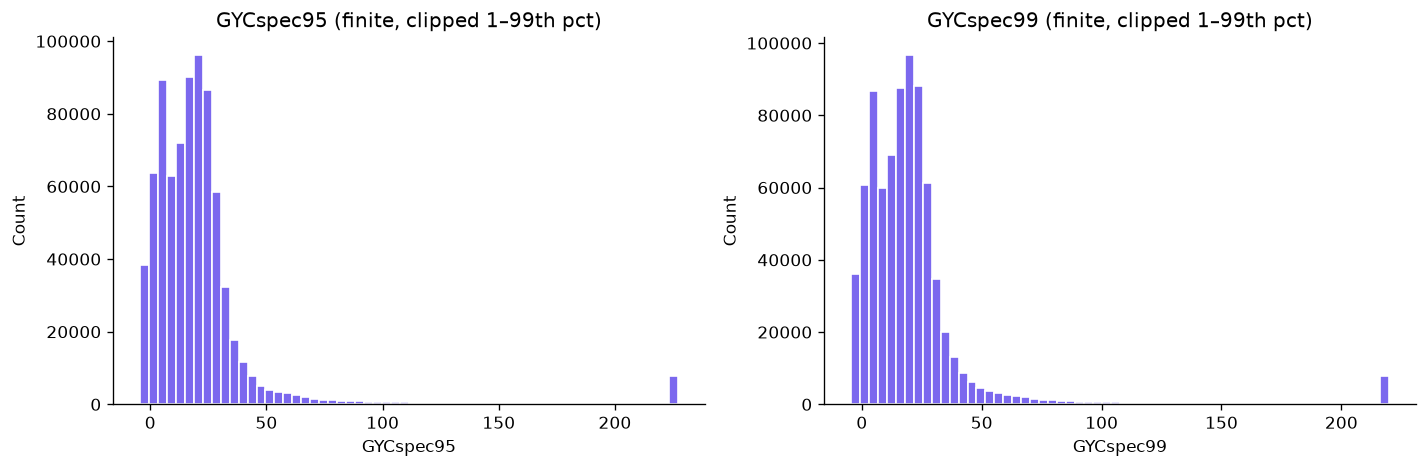

In [32]:
# ── GYCspec95/99 — general yield class from specific height ──
gyc95_finite = df["GYCspec95"][np.isfinite(df["GYCspec95"])]
gyc99_finite = df["GYCspec99"][np.isfinite(df["GYCspec99"])]
print("GYCspec95 (finite only):")
print(gyc95_finite.describe().round(2))
print(f"\nInfinite values in GYCspec95: {np.isinf(df['GYCspec95']).sum():,}")
print(f"Infinite values in GYCspec99: {np.isinf(df['GYCspec99']).sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (col, vals) in zip(axes, [("GYCspec95", gyc95_finite), ("GYCspec99", gyc99_finite)]):
    clip = vals.clip(*vals.quantile([0.01, 0.99]))
    ax.hist(clip, bins=60, color="mediumslateblue", edgecolor="white")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.set_title(f"{col} (finite, clipped 1–99th pct)")
plt.tight_layout()
plt.show()


### Summary — Key Forest Variables
- `Top_Height99` is counterintuitively *lower* than `Top_Height95` in roughly a quarter of rows — the two metrics are not interchangeable. Investigate before choosing one for modelling; `Top_Height95` is the conventional forestry choice.
- `Vol_RM95` has small negative values (running-mean artefact); `Vol95`/`Vol99` are positive but have 5 102 missing rows.
- The LAI ceiling at 5.5 (sensor saturation) affects a significant number of rows — this is inherited from the old dataset.
- `spis` and `Species` columns disagree in a large fraction of rows. `spis` drives yield-class calculations; `Species` appears to be a separate classification. Don't use them interchangeably.
- `g1` and `g3` have only ~10 unique values each and cross-tabulate exactly with `Thin` and `spis`. They are per-plot volume equation coefficients, not independent variables — exclude from model inputs.
- `p1–p5` have only 4–6 unique values — tabulated lookup parameters, not plot-level measurements.
- `GYCspec95/99` contain 4 278 infinite values. Even the finite range is very wide (max ~17 000 m³ ha⁻¹ yr⁻¹), indicating numerical instability. Treat with caution or exclude.
- `whcl` (wind hazard class 0–6, no missing values) is the only genuinely independent environmental variable currently in the dataset.


---
## 4. Relationships and Correlations


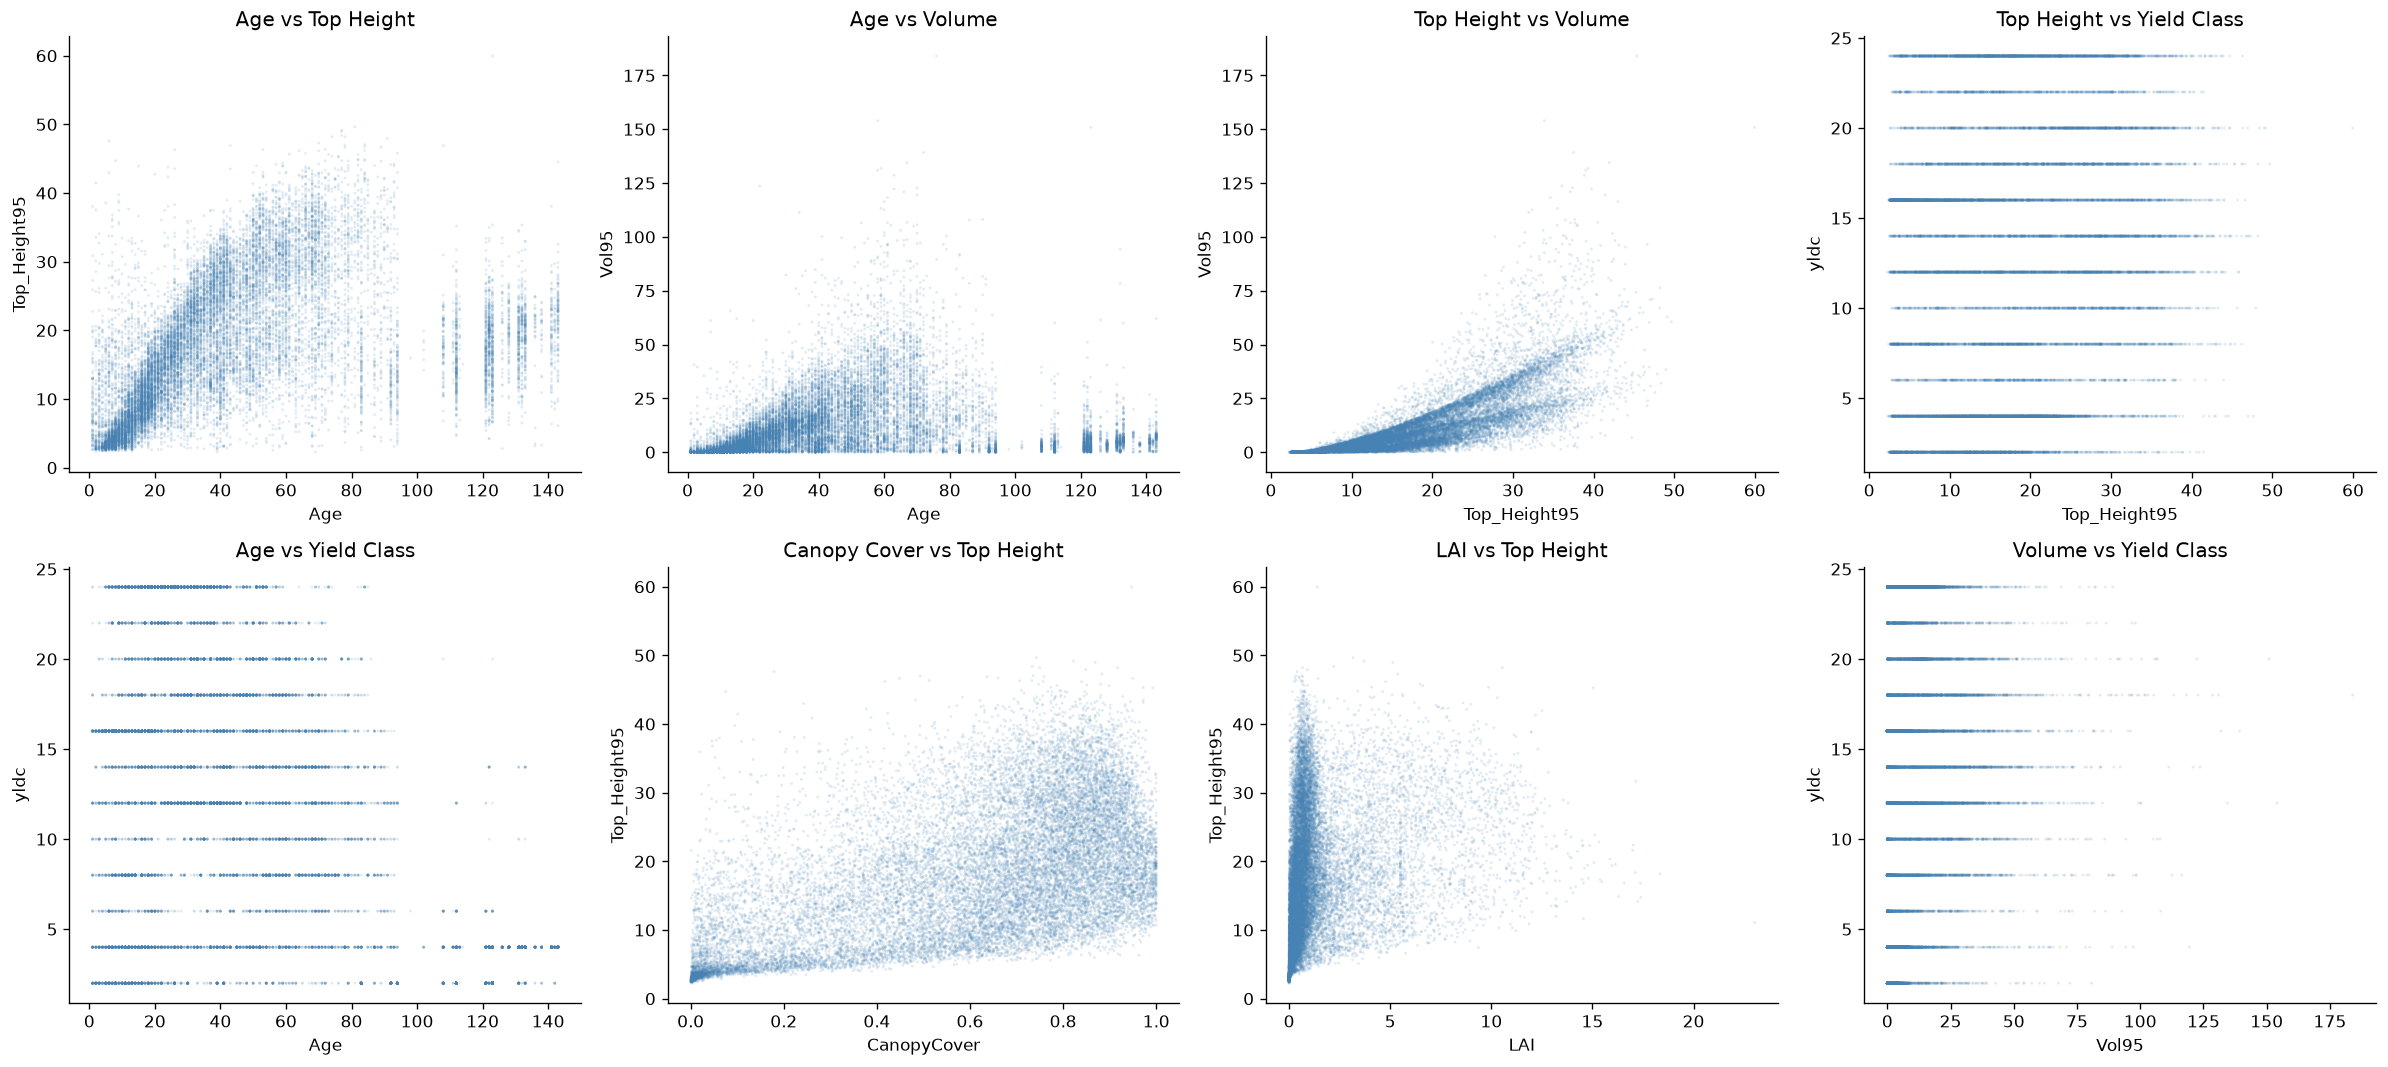

In [33]:
# Pairwise scatter plots for the core growth variables.
# Use a 20 000-row sample to keep rendering fast.
rng = np.random.default_rng(42)
idx = rng.choice(len(df), size=min(20_000, len(df)), replace=False)
sample = df.iloc[idx].copy()

pairs = [
    ("Age", "Top_Height95", "Age vs Top Height"),
    ("Age", "Vol95",        "Age vs Volume"),
    ("Top_Height95", "Vol95", "Top Height vs Volume"),
    ("Top_Height95", "yldc",  "Top Height vs Yield Class"),
    ("Age", "yldc",           "Age vs Yield Class"),
    ("CanopyCover", "Top_Height95", "Canopy Cover vs Top Height"),
    ("LAI", "Top_Height95",   "LAI vs Top Height"),
    ("Vol95", "yldc",         "Volume vs Yield Class"),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, (x, y, title) in zip(axes.flat, pairs):
    sub = sample[[x, y]].replace(0, np.nan).dropna()
    ax.scatter(sub[x], sub[y], s=3, alpha=0.15, color="steelblue", edgecolor="none")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title)

plt.tight_layout()
plt.show()


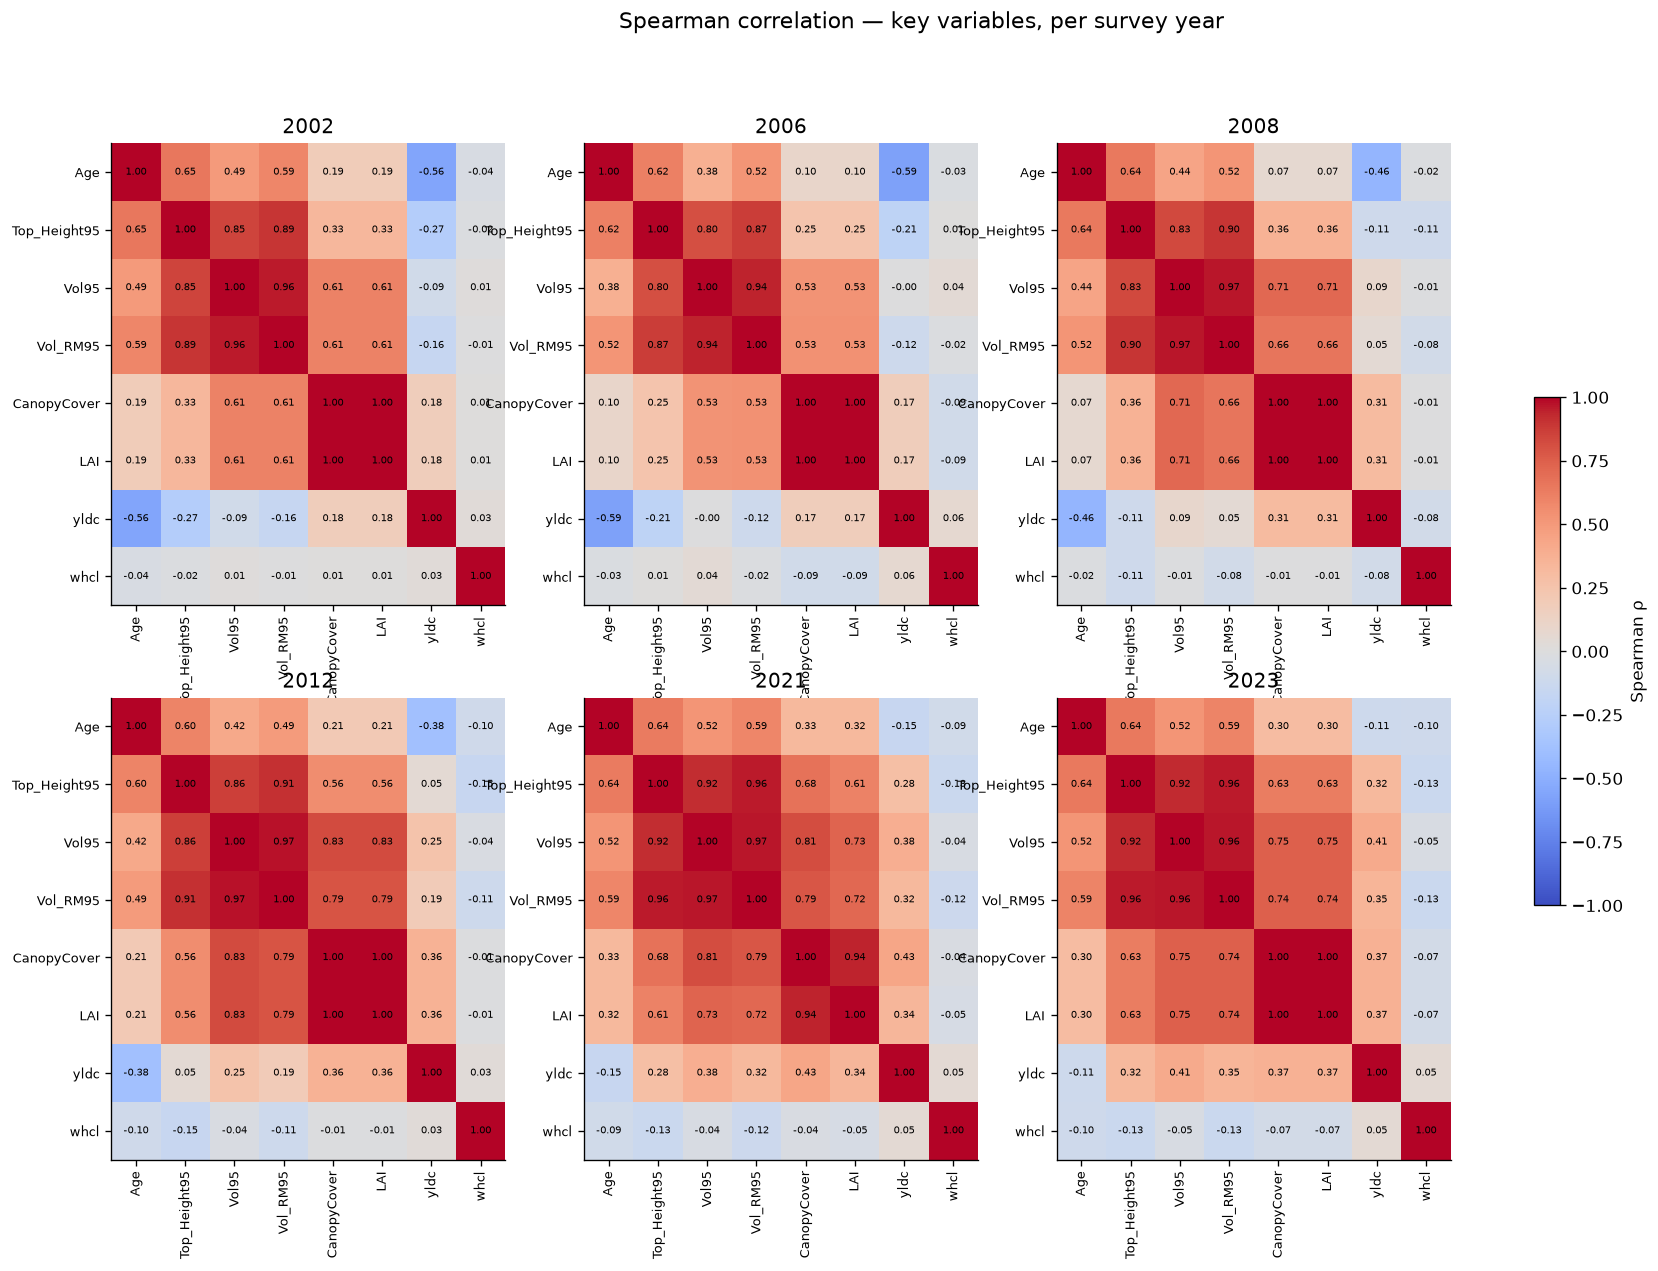

In [35]:
# Spearman correlation matrix — per survey year.
corr_vars = ["Age", "Top_Height95", "Vol95", "Vol_RM95",
             "CanopyCover", "LAI", "yldc", "whcl"]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for ax, (yr, grp) in zip(axes.flat, df.groupby("LiDAR_year")):
    sub = grp[corr_vars].replace(0, np.nan)  # treat 0-sentinels as NaN
    corr = sub.corr(method="spearman")
    im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(corr_vars)))
    ax.set_xticklabels(corr_vars, rotation=90, fontsize=8)
    ax.set_yticks(range(len(corr_vars)))
    ax.set_yticklabels(corr_vars, fontsize=8)
    ax.set_title(str(yr))
    for r in range(len(corr_vars)):
        for c in range(len(corr_vars)):
            ax.text(c, r, f"{corr.iloc[r, c]:.2f}", ha="center", va="center", fontsize=6)

fig.colorbar(im, ax=axes, shrink=0.5, label="Spearman ρ")
fig.suptitle("Spearman correlation — key variables, per survey year", fontsize=13)
plt.show()


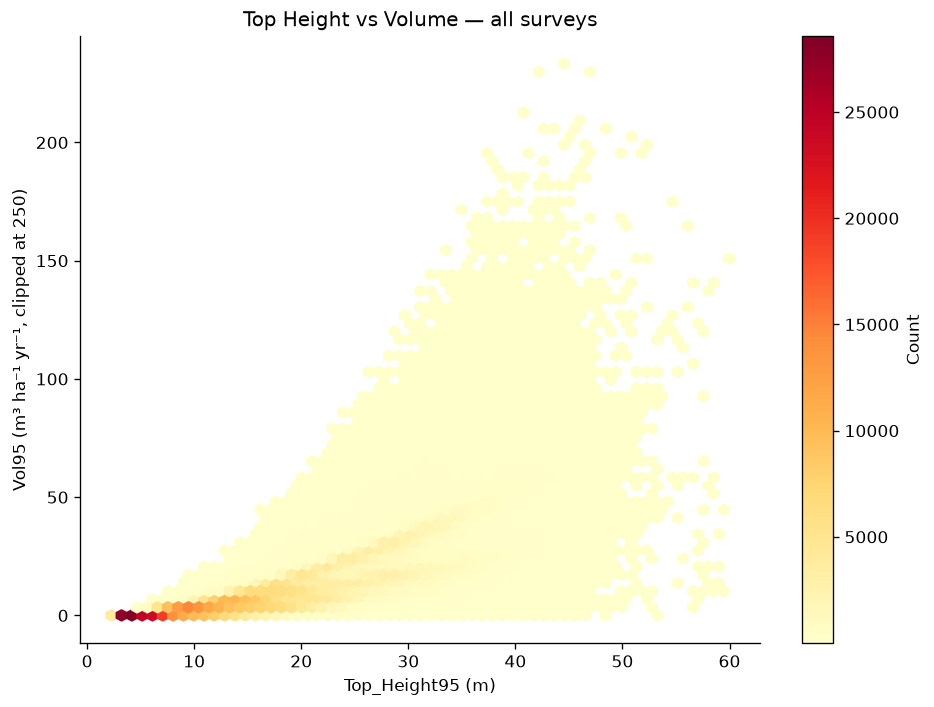

In [36]:
# Top-height vs volume hexbin — all years.
valid = df[["Top_Height95", "Vol95"]].dropna()
fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(valid["Top_Height95"], valid["Vol95"].clip(upper=250),
               gridsize=60, cmap="YlOrRd", mincnt=1)
fig.colorbar(hb, ax=ax, label="Count")
ax.set_xlabel("Top_Height95 (m)")
ax.set_ylabel("Vol95 (m³ ha⁻¹ yr⁻¹, clipped at 250)")
ax.set_title("Top Height vs Volume — all surveys")
plt.tight_layout()
plt.show()


### Summary — Relationships and Correlations
- Age vs Top_Height95 shows clear but noisy growth trend — the scatter is real (different yield classes, species, and thinning histories).
- Top_Height95 and Vol95 are strongly correlated but nonlinearly — consistent with the power-law volume equations.
- Yield class (yldc) correlates moderately with height and volume but shows plateau behaviour — it's a categorical lookup more than a continuous measurement.
- CanopyCover and LAI are highly correlated with each other (expected: `GapFraction = 1 − CanopyCover`, `LAI` derived from gap fraction). Avoid using both in the same model.
- `whcl` shows weak to moderate correlation with growth variables — potentially useful as an independent environmental driver.
- Correlations are broadly consistent across years, suggesting no systematic sensor shift between surveys (though 2021 LAI anomaly warrants checking in the cleaning notebook).
